In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langchain_groq import ChatGroq
from langgraph.graph import START, END
from langgraph.graph.message import add_messages
from langgraph.graph.state import StateGraph
from  langgraph.prebuilt import ToolNode , tools_condition
from langchain_core.messages import BaseMessage
from langchain_core.tools import tool
import os


In [2]:
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv

load_dotenv()
groq_api_key = os.getenv("GROQ_API_KEY")

model = init_chat_model("openai/gpt-oss-120b", model_provider="GROQ")
model
##Langsmit API KEY
langsmith_api_key = os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "Chabot-debugging"

In [3]:
##Create Stategraph


class State(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]


##Graph with tool call

@tool
def add(a: float, b: float) -> float:
    """Add two numbers"""
    return a + b


tool_node = ToolNode([add])
tools=[add]

In [4]:
llm_with_tool=model.bind_tools([add])

In [5]:
def call_llm_model(state: State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

In [6]:
##Build the graph with StateGrapgh
builder = StateGraph(State)

##Build Nodes - 1st node always llm call
builder.add_node("call_llm_model", call_llm_model)
builder.add_node("tools", ToolNode(tools))

## Add Edges

builder.add_edge(START, "call_llm_model")
builder.add_conditional_edges("call_llm_model", tools_condition)
builder.add_edge("tools", "call_llm_model")

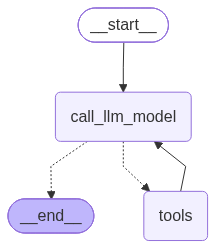

In [7]:
##Compile the graph and Show the tool
graph=builder.compile()

##Display graph
from IPython.display import Image,display
display(Image(graph.get_graph().draw_mermaid_png()))


In [8]:
response=graph.invoke({"messages":"What is the latest ai news?"})

In [9]:
response = graph.invoke({"messages": "What is the result of adding 268 and 98765? Use the add tool.?"})


In [10]:
response

{'messages': [HumanMessage(content='What is the result of adding 268 and 98765? Use the add tool.?', additional_kwargs={}, response_metadata={}, id='2f868a55-b0e9-4aa5-a7b3-6415abf90189'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "We need to use add tool with a=268, b=98765. Compute sum: 98765+268 = 99033? Let's calculate: 98765+200=98965, +68=99033. Yes. Use tool.", 'tool_calls': [{'id': 'fc_ea207917-85a7-4fa8-a728-08870de74e1b', 'function': {'arguments': '{"a":268,"b":98765}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 87, 'prompt_tokens': 138, 'total_tokens': 225, 'completion_time': 0.189137679, 'completion_tokens_details': {'reasoning_tokens': 53}, 'prompt_time': 0.006723951, 'prompt_tokens_details': None, 'queue_time': 0.350006826, 'total_time': 0.19586163}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_fe269835c7', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': Non